# UrbanSound8K with Pytorch

## Steps to do data training, validating, and testing

### 1. Import libraries

In [1]:
import os
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Define dataset class

In [2]:
class CustomDataset(Dataset):
    def __init__(self, data_path, transform=None):
        self.data_path = data_path
        self.transform = transform
        self.classes = os.listdir(data_path)  # List subdirectories (classes)
        self.files = []
        for label, class_name in enumerate(self.classes):
            class_path = os.path.join(data_path, class_name)
            for file_name in os.listdir(class_path):
                if file_name.endswith('.npy'):
                    self.files.append((class_name, os.path.join(class_path, file_name)))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        class_name, file_path = self.files[idx]
        data = np.load(file_path)  # Load the .npy file (spectrogram)
        label = self.classes.index(class_name)

        if self.transform:
            data = self.transform(data)

        return data, label

### 3. Define transformations

In [3]:
transform = transforms.Compose([
    transforms.Lambda(lambda x: torch.tensor(x).unsqueeze(0).repeat(3, 1, 1)),  # Convert numpy array to tensor and repeat the channel
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Use ImageNet's standard normalization
    # transforms.Lambda(lambda x: (x - x.mean()) / x.std()),  # Z-score normalization
])

### 4. Define training, validating and testing paths

In [4]:
train_val_path = 'train_val_spectrogram_npy'  # Replace with your training/validation data path
test_path = 'test_spectrogram_npy'  # Replace with your test data path

### 5. Load training, validating dataset

In [5]:
train_val_dataset = CustomDataset(data_path=train_val_path, transform=transform)

### 6. Split training, validating dataset into train and validation

In [6]:
train_size = int(0.9 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

### 7. Create train and validation dataloaders

In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### 8. Load test dataset

In [8]:
test_dataset = CustomDataset(data_path=test_path, transform=transform)

### 9. Create test dataloader

In [9]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### 10. Initialize ResNet50 model

In [10]:
model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)  # Using the recommended weights argument
model.fc = nn.Linear(model.fc.in_features, 8)  # 8 classes

### 11. Move model to GPU if available

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

### 12. Define loss function and optimizer

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 13. Set up ReduceLROnPlateau scheduler

In [13]:
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

### 14. Set up Early Stopping

In [14]:
patience = 10  # Define a patience value
best_val_loss = float('inf')  # Initialize with a high value
epochs_since_improvement = 0

### 15. Train and validate model

In [15]:
epochs = 200
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total * 100
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {train_accuracy:.2f}%")

    # Validate the model
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_accuracy = val_correct / val_total * 100
    print(f"Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_accuracy:.2f}%")

    # Step the scheduler based on validation loss
    scheduler.step(val_loss / len(val_loader))

    # Print the learning rate manually (using get_last_lr)
    print(f"Learning rate: {optimizer.param_groups[0]['lr']}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_since_improvement = 0
        # Save the model if validation loss improves
        torch.save(model.state_dict(), 'best_resnet50_spectrogram_model.pth')
    else:
        epochs_since_improvement += 1

    if epochs_since_improvement >= patience:
        print("Early stopping: No improvement in validation loss for several epochs.")
        break

Epoch [1/200], Loss: 1.1305, Accuracy: 62.65%
Validation Loss: 1.0536, Validation Accuracy: 63.61%
Learning rate: 0.001
Epoch [2/200], Loss: 0.5977, Accuracy: 81.02%
Validation Loss: 0.7066, Validation Accuracy: 76.94%
Learning rate: 0.001
Epoch [3/200], Loss: 0.4214, Accuracy: 86.20%
Validation Loss: 0.6968, Validation Accuracy: 75.56%
Learning rate: 0.001
Epoch [4/200], Loss: 0.3534, Accuracy: 89.04%
Validation Loss: 0.5695, Validation Accuracy: 80.83%
Learning rate: 0.001
Epoch [5/200], Loss: 0.2888, Accuracy: 90.59%
Validation Loss: 0.6470, Validation Accuracy: 79.17%
Learning rate: 0.001
Epoch [6/200], Loss: 0.2428, Accuracy: 92.07%
Validation Loss: 0.3698, Validation Accuracy: 89.44%
Learning rate: 0.001
Epoch [7/200], Loss: 0.1700, Accuracy: 94.41%
Validation Loss: 1.3437, Validation Accuracy: 67.50%
Learning rate: 0.001
Epoch [8/200], Loss: 0.2072, Accuracy: 93.33%
Validation Loss: 0.5246, Validation Accuracy: 83.61%
Learning rate: 0.001
Epoch [9/200], Loss: 0.1347, Accuracy: 9

### 16. Save model after training is completed

In [16]:
torch.save(model.state_dict(), 'resnet50_spectrogram_model.pth')  # Save final model weights

### 17. Load the saved model weights for testing

In [17]:
model.load_state_dict(torch.load('resnet50_spectrogram_model.pth', weights_only=True))  # Load model weights

<All keys matched successfully>

### 18. Evaluate on test data

In [18]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())  # Collect true labels
        all_predictions.extend(predicted.cpu().numpy())  # Collect predicted labels

### 19. Compute, print, and save confusion matrix

Confusion Matrix:
[[50  0  0  0  0  0  0  0]
 [ 0 47  1  1  0  0  1  0]
 [ 0  4 45  1  0  0  0  0]
 [ 0  0  0 49  0  1  0  0]
 [ 0  0  0  0 50  0  0  0]
 [ 0  1  0  1  0 48  0  0]
 [ 0  1  0  0  0  0 49  0]
 [ 0  3  0  1  0  1  0 45]]


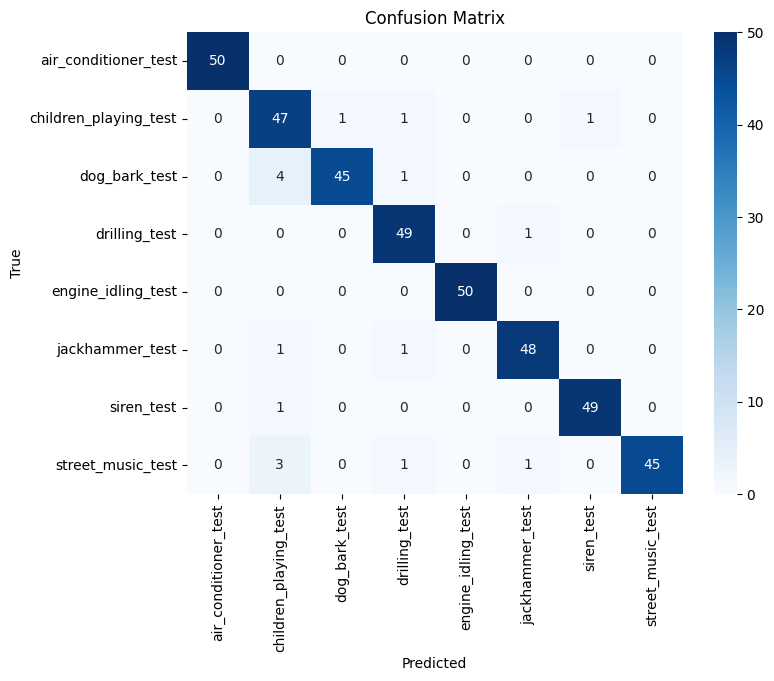

In [19]:
conf_matrix = confusion_matrix(all_labels, all_predictions)

print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')

### 20. Compute, print, and save classification report

In [20]:
class_report = classification_report(all_labels, all_predictions, target_names=test_dataset.classes)

print("Classification Report:")
print(class_report)

with open('classification_report.txt', 'w') as f:
    f.write(class_report)

Classification Report:
                       precision    recall  f1-score   support

 air_conditioner_test       1.00      1.00      1.00        50
children_playing_test       0.84      0.94      0.89        50
        dog_bark_test       0.98      0.90      0.94        50
        drilling_test       0.92      0.98      0.95        50
   engine_idling_test       1.00      1.00      1.00        50
      jackhammer_test       0.96      0.96      0.96        50
           siren_test       0.98      0.98      0.98        50
    street_music_test       1.00      0.90      0.95        50

             accuracy                           0.96       400
            macro avg       0.96      0.96      0.96       400
         weighted avg       0.96      0.96      0.96       400

